1. Load data
2. Split into X_train, X_test
3. Handle missing values / cleaning
4. StandardScaler (fit on train only)
5. Feature selection (fit on train only)
6. Model selection
7. GridSearchCV + cross-validation
8. Final evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chethuhn/network-intrusion-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'network-intrusion-dataset' dataset.
Path to dataset files: /kaggle/input/network-intrusion-dataset


In [3]:
import os
print(os.listdir(path))

['Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']


In [4]:
df = pd.read_csv(path + '/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv')

In [5]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [6]:
df.tail()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
286462,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286463,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286464,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286465,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286466,443,186928,46,57,1319,100049,570,0,28.673913,111.438085,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [7]:
df[' Label'].value_counts()

,count
Label,
PortScan,158930
BENIGN,127537


In [8]:
df.shape

(286467, 79)

Converting



*   Benign -> 0

*   Malicious -> 1



In [9]:
df['target'] = df[' Label'].map({
    'BENIGN': 0,
    'PortScan': 1
})

In [10]:
X = df.drop([' Label', 'target'], axis=1)
y = df['target']

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [12]:
y_train.value_counts()

,count
target,
1,127144
0,102029


In [13]:
print(X_train.isnull().sum())

 Destination Port              0
 Flow Duration                 0
 Total Fwd Packets             0
 Total Backward Packets        0
Total Length of Fwd Packets    0
                              ..
 Active Min                    0
Idle Mean                      0
 Idle Std                      0
 Idle Max                      0
 Idle Min                      0
Length: 78, dtype: int64


In [14]:
print(X_test.isnull().any())

 Destination Port              False
 Flow Duration                 False
 Total Fwd Packets             False
 Total Backward Packets        False
Total Length of Fwd Packets    False
                               ...  
 Active Min                    False
Idle Mean                      False
 Idle Std                      False
 Idle Max                      False
 Idle Min                      False
Length: 78, dtype: bool


In [15]:
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

In [16]:
bytes_median = X_train['Flow Bytes/s'].median()
packets_median = X_train[' Flow Packets/s'].median()

# 4. fill NaNs
X_train['Flow Bytes/s'].fillna(bytes_median, inplace=True)
X_test['Flow Bytes/s'].fillna(bytes_median, inplace=True)

X_train[' Flow Packets/s'].fillna(packets_median, inplace=True)
X_test[' Flow Packets/s'].fillna(packets_median, inplace=True)

/tmp/ipykernel_7541/940157902.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Flow Bytes/s'].fillna(bytes_median, inplace=True)
/tmp/ipykernel_7541/940157902.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

In [17]:
print(X_train.isnull().any())

 Destination Port              False
 Flow Duration                 False
 Total Fwd Packets             False
 Total Backward Packets        False
Total Length of Fwd Packets    False
                               ...  
 Active Min                    False
Idle Mean                      False
 Idle Std                      False
 Idle Max                      False
 Idle Min                      False
Length: 78, dtype: bool


In [18]:
print(X_train.isnull().any())

 Destination Port              False
 Flow Duration                 False
 Total Fwd Packets             False
 Total Backward Packets        False
Total Length of Fwd Packets    False
                               ...  
 Active Min                    False
Idle Mean                      False
 Idle Std                      False
 Idle Max                      False
 Idle Min                      False
Length: 78, dtype: bool


In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42
    )
}

In [29]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, classification_report

k_values = [25]
for k in k_values:
    print(f"\n===== k = {k} =====")

    selector = SelectKBest(f_classif, k=k)

    X_train_k = selector.fit_transform(X_scaled, y_train)
    X_test_k = selector.transform(X_test_scaled)

    for name, model in models.items():

        model_copy = model  # safer if reused carefully

        model_copy.fit(X_train_k, y_train)
        y_pred = model_copy.predict(X_test_k)

        acc = accuracy_score(y_test, y_pred)

        print(f"\n{name}: {acc:.4f}")
        print(classification_report(y_test, y_pred))


===== k = 25 =====


/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [31 32 33 49 56 57 58 59 60 61] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Logistic Regression: 0.9958
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     25508
           1       0.99      1.00      1.00     31786

    accuracy                           1.00     57294
   macro avg       1.00      1.00      1.00     57294
weighted avg       1.00      1.00      1.00     57294


Random Forest: 0.9999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25508
           1       1.00      1.00      1.00     31786

    accuracy                           1.00     57294
   macro avg       1.00      1.00      1.00     57294
weighted avg       1.00      1.00      1.00     57294



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:54:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost: 0.9998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     25508
           1       1.00      1.00      1.00     31786

    accuracy                           1.00     57294
   macro avg       1.00      1.00      1.00     57294
weighted avg       1.00      1.00      1.00     57294



In [30]:
selected_features = X_train.columns[selector.get_support()]

X_train_k = pd.DataFrame(X_train_k, columns=selected_features)

corr_matrix = X_train_k.corr()

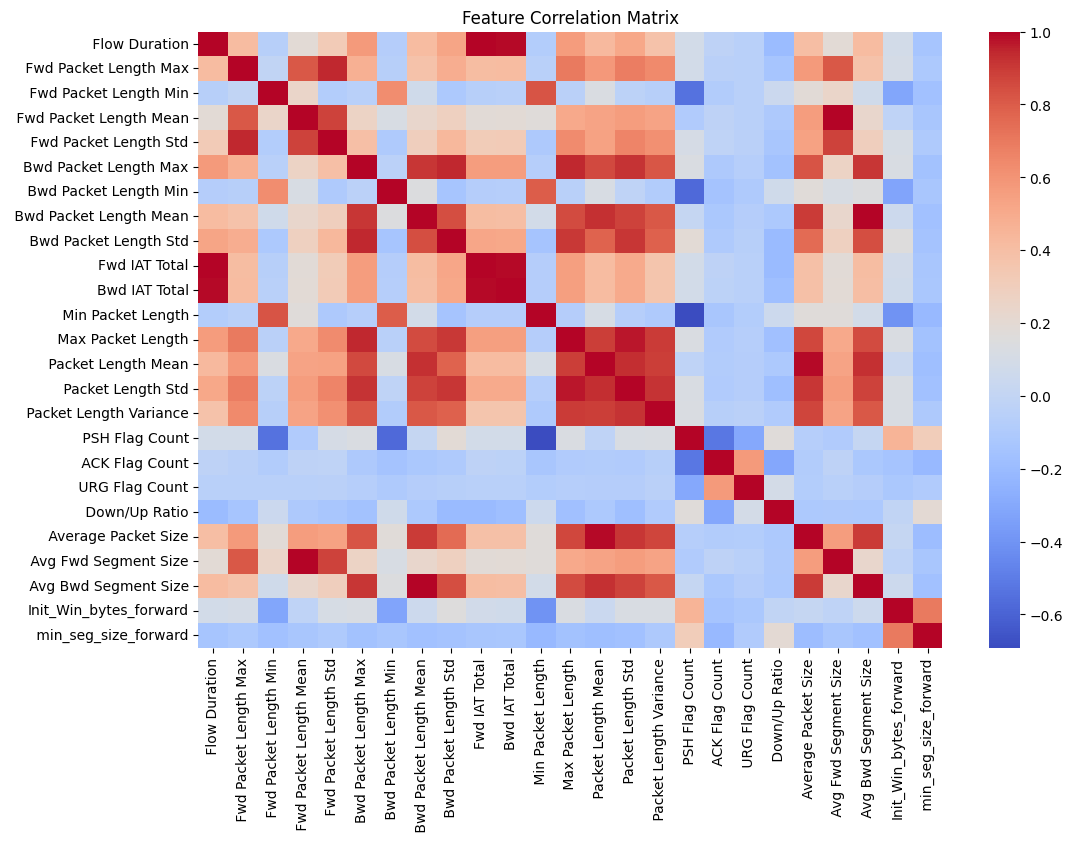

In [31]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [41]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(RandomForestClassifier(n_estimators=100,random_state=42), X_train_k, y_train, cv=5)
print(scores.mean())

0.9999345474538173


In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[25505     3]
 [    6 31780]]


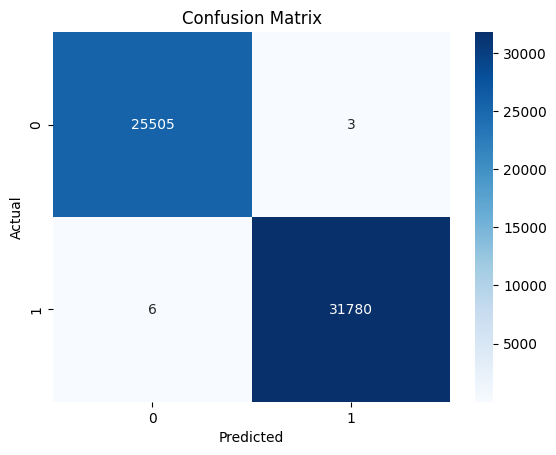

In [43]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [44]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test_k)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

print("AUC:", auc_score)

AUC: 0.9999976553942297


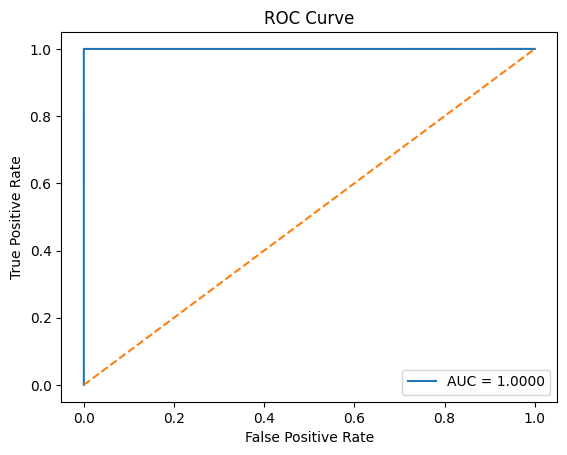

In [45]:
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [46]:
risk_score = y_prob * 100

In [47]:
def classify_threat(prob):
    risk_score = prob * 100

    if risk_score >= 70:
        return "BLOCK", risk_score
    elif risk_score >= 30:
        return "MONITOR", risk_score
    else:
        return "ALLOW", risk_score

In [48]:
results = [classify_threat(p) for p in y_prob]

actions = [r[0] for r in results]
scores = [r[1] for r in results]

In [49]:
df_results = pd.DataFrame({
    "Probability": y_prob,
    "Risk_Score": risk_score,
    "Action": actions
})

print(df_results.tail())

        Probability  Risk_Score Action
57289  9.999993e-01   99.999931  BLOCK
57290  2.863451e-07    0.000029  ALLOW
57291  1.977571e-07    0.000020  ALLOW
57292  3.759046e-07    0.000038  ALLOW
57293  9.999993e-01   99.999931  BLOCK


In [50]:
import joblib

joblib.dump(model, "rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selector, "selector.pkl")

joblib.dump(X_train.columns, "feature_names.pkl")

['feature_names.pkl']